# Refinamiento de arquitectura: MLP profunda

XGBoost + ROS sigue siendo el modelo final del proyecto (ver `06_refinamiento_modelo.ipynb`); este notebook no reabre esa selección. Su objetivo es distinto: demostrar el proceso de refinamiento de una arquitectura de red neuronal, ensayando variantes de la MLP profunda (la mejor red del notebook 05 en recall, ROC-AUC y PR-AUC) y comparándolas entre sí sobre el conjunto de validación.

Se reutiliza la misma lógica de entrenamiento del notebook 05 (lotes de 256, máximo 30 épocas, paciencia 5), pero **cada una de las tres configuraciones se entrena con su propio `DataLoader`, reiniciado con la semilla 42 antes de empezar**, para que las tres reciban exactamente el mismo orden de lotes entre sí y la comparación A/B/C sea justa. Por esta razón, los números de la configuración A (baseline) no coinciden de forma exacta con los del notebook 05: allí la MLP profunda se entrenó en segundo lugar de tres redes que compartían un único generador de aleatoriedad, por lo que el orden de lotes que le tocó no es el mismo que el de "entrenarla sola desde el inicio" que se usa aquí. La diferencia es una variación esperable por el orden de entrenamiento, no un error de configuración — la arquitectura, el `pos_weight`, el optimizador y los demás hiperparámetros son idénticos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)

Dispositivo: cpu


## 1. Carga de artefactos y preparación de tensores

In [2]:
ruta_artefactos = Path("../artifacts")
ruta_modelos = Path("../models")
ruta_figuras = Path("../figures")

artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")

X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
y_train = artefactos["y_train"].to_numpy().astype("float32")
y_val = artefactos["y_val"].to_numpy().astype("float32")

def a_denso(matriz):
    return matriz.toarray().astype("float32") if hasattr(matriz, "toarray") else matriz.astype("float32")

X_train_denso = a_denso(X_train)
X_val_denso = a_denso(X_val)
n_variables = X_train_denso.shape[1]

train_dataset = TensorDataset(torch.from_numpy(X_train_denso), torch.from_numpy(y_train))
X_val_tensor = torch.from_numpy(X_val_denso).to(DEVICE)
y_val_tensor = torch.from_numpy(y_val).to(DEVICE)

relacion_desbalance = (y_train == 0).sum() / (y_train == 1).sum()
print("Relación de desbalance:", round(float(relacion_desbalance), 3))
print("X_train:", X_train_denso.shape, "| X_val:", X_val_denso.shape)

Relación de desbalance: 8.79
X_train: (7000, 58) | X_val: (1500, 58)


## 2. Arquitecturas

- **A — Baseline** (la del notebook 05): 58-128-64-32-1, `BatchNorm1d` y
  dropout 0,3 en cada capa oculta.
- **B — Regularizada y más angosta**: 58-64-32-1, dropout 0,2, con
  `weight_decay` explícito más alto y un programador `ReduceLROnPlateau`.
  Con solo 7.000 filas de entrenamiento, la red de 128 neuronas de la capa A
  tiene capacidad de sobra para sobreajustar; esta variante prueba si una
  red más chica generaliza igual de bien o mejor.
- **C — Orientada a precisión**: misma arquitectura que A, pero con un
  `pos_weight` más suave (raíz cuadrada de la relación de desbalance, en vez
  de la relación completa) y detención temprana basada en PR-AUC de
  validación en vez de ROC-AUC. Un `pos_weight` tan alto como el original
  empuja al modelo a maximizar recall a costa de la precision; esta variante
  prueba si suavizarlo mejora el equilibrio.

In [3]:
class MLPProfundaBase(nn.Module):
    def __init__(self, n_entradas, dropout=0.3):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_entradas, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.red(x).squeeze(-1)


class MLPProfundaRegularizada(nn.Module):
    def __init__(self, n_entradas, dropout=0.2):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_entradas, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.red(x).squeeze(-1)

## 3. Función de entrenamiento (misma lógica que el notebook 05, generalizada)

Se agregan tres parámetros configurables respecto al notebook 05:
`pos_weight`, `weight_decay` y la métrica sobre la que se mide la mejora
para la detención temprana (ROC-AUC o PR-AUC), además de un programador de
tasa de aprendizaje opcional.

In [4]:
def entrenar_configuracion(
    modelo,
    nombre,
    pos_weight_valor,
    weight_decay=0.01,
    usar_scheduler=False,
    metrica_parada="roc_auc",
    paciencia=5,
    max_epocas=30,
):
    modelo.to(DEVICE)

    # DataLoader propio, con semilla reiniciada: todas las configuraciones
    # de este notebook reciben el mismo orden de lotes entre sí.
    generador = torch.Generator().manual_seed(RANDOM_STATE)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=generador)

    pos_weight = torch.tensor([pos_weight_valor], dtype=torch.float32, device=DEVICE)
    funcion_perdida = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizador = torch.optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=weight_decay)
    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode="max", patience=2)
        if usar_scheduler
        else None
    )

    mejor_metrica = -np.inf
    mejor_estado = None
    epocas_sin_mejora = 0
    historial = []

    for epoca in range(1, max_epocas + 1):
        modelo.train()
        perdida_acumulada = 0.0

        for lote_X, lote_y in train_loader:
            lote_X, lote_y = lote_X.to(DEVICE), lote_y.to(DEVICE)

            optimizador.zero_grad()
            logits = modelo(lote_X)
            perdida = funcion_perdida(logits, lote_y)
            perdida.backward()
            optimizador.step()

            perdida_acumulada += perdida.item() * lote_X.size(0)

        perdida_promedio = perdida_acumulada / len(train_loader.dataset)

        modelo.eval()
        with torch.no_grad():
            logits_val = modelo(X_val_tensor)
            perdida_val = funcion_perdida(logits_val, y_val_tensor).item()
            proba_val = torch.sigmoid(logits_val).cpu().numpy()

        roc_auc_val = roc_auc_score(y_val, proba_val)
        pr_auc_val = average_precision_score(y_val, proba_val)
        metrica_actual = roc_auc_val if metrica_parada == "roc_auc" else pr_auc_val

        historial.append({
            "epoca": epoca,
            "perdida_entrenamiento": perdida_promedio,
            "perdida_val": perdida_val,
            "roc_auc_val": roc_auc_val,
            "pr_auc_val": pr_auc_val,
        })

        if scheduler is not None:
            scheduler.step(metrica_actual)

        if metrica_actual > mejor_metrica:
            mejor_metrica = metrica_actual
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        if epocas_sin_mejora >= paciencia:
            print(f"[{nombre}] early stopping en época {epoca} (mejor {metrica_parada} val: {mejor_metrica:.4f})")
            break

    modelo.load_state_dict(mejor_estado)
    print(f"[{nombre}] entrenamiento finalizado - mejor {metrica_parada} val: {mejor_metrica:.4f} en {len(historial)} épocas")

    return modelo, pd.DataFrame(historial)

## 4. Entrenamiento de las tres configuraciones

In [5]:
torch.manual_seed(RANDOM_STATE)
modelo_a, historial_a = entrenar_configuracion(
    MLPProfundaBase(n_variables, dropout=0.3),
    "A - Baseline",
    pos_weight_valor=relacion_desbalance,
    weight_decay=0.01,
    usar_scheduler=False,
    metrica_parada="roc_auc",
)

[A - Baseline] early stopping en época 14 (mejor roc_auc val: 0.7613)
[A - Baseline] entrenamiento finalizado - mejor roc_auc val: 0.7613 en 14 épocas


In [6]:
torch.manual_seed(RANDOM_STATE)
modelo_b, historial_b = entrenar_configuracion(
    MLPProfundaRegularizada(n_variables, dropout=0.2),
    "B - Regularizada",
    pos_weight_valor=relacion_desbalance,
    weight_decay=0.02,
    usar_scheduler=True,
    metrica_parada="roc_auc",
)

[B - Regularizada] early stopping en época 16 (mejor roc_auc val: 0.7770)
[B - Regularizada] entrenamiento finalizado - mejor roc_auc val: 0.7770 en 16 épocas


In [7]:
torch.manual_seed(RANDOM_STATE)
modelo_c, historial_c = entrenar_configuracion(
    MLPProfundaBase(n_variables, dropout=0.3),
    "C - Orientada a precisión",
    pos_weight_valor=np.sqrt(relacion_desbalance),
    weight_decay=0.01,
    usar_scheduler=False,
    metrica_parada="pr_auc",
)

[C - Orientada a precisión] early stopping en época 17 (mejor pr_auc val: 0.2441)
[C - Orientada a precisión] entrenamiento finalizado - mejor pr_auc val: 0.2441 en 17 épocas


## 5. Convergencia y error: curvas de pérdida

Para justificar la arquitectura no basta con las métricas finales: también hay que mostrar cómo convergió cada configuración durante el entrenamiento. Se grafica la pérdida (`BCEWithLogitsLoss`) de entrenamiento y de validación por época, junto con la época en la que se alcanzó el mejor valor de la métrica de parada (marcada con una línea vertical).

Se usan **tres paneles separados, uno por configuración**, en vez de un solo gráfico compartido: la configuración C usa un `pos_weight` distinto al de A y B (raíz cuadrada de la relación de desbalance, en vez de la relación completa), por lo que su pérdida está en una escala distinta y no es directamente comparable con las otras dos. Comparar los valores absolutos de pérdida entre paneles no es válido; lo que sí es comparable entre configuraciones son las métricas (ROC-AUC, PR-AUC, F1) de la sección 6.

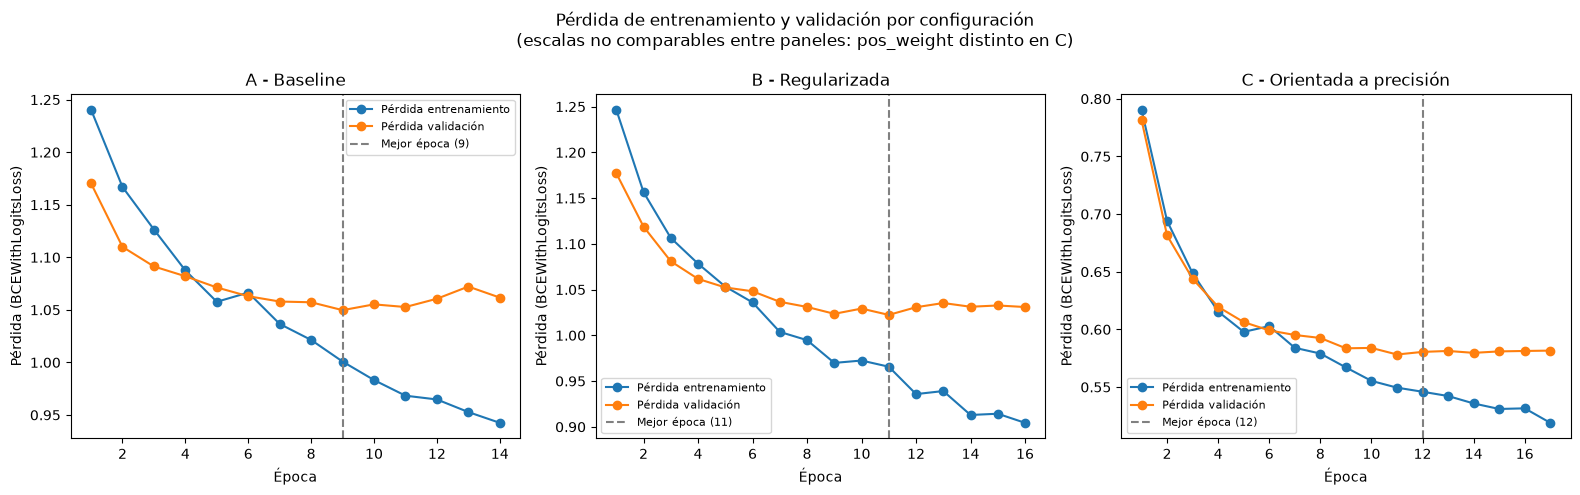

A - Baseline: mejor época = 9 | pérdida train = 1.0008 | pérdida val = 1.0497
B - Regularizada: mejor época = 11 | pérdida train = 0.9657 | pérdida val = 1.0223
C - Orientada a precisión: mejor época = 12 | pérdida train = 0.5459 | pérdida val = 0.5805


In [8]:
def epoca_optima(historial, metrica_parada):
    columna = "roc_auc_val" if metrica_parada == "roc_auc" else "pr_auc_val"
    fila_mejor = historial.loc[historial[columna].idxmax()]
    return int(fila_mejor["epoca"])


configuraciones_perdida = [
    ("A - Baseline", historial_a, "roc_auc"),
    ("B - Regularizada", historial_b, "roc_auc"),
    ("C - Orientada a precisión", historial_c, "pr_auc"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, historial, metrica_parada) in zip(axes, configuraciones_perdida):
    mejor_epoca = epoca_optima(historial, metrica_parada)

    ax.plot(historial["epoca"], historial["perdida_entrenamiento"], marker="o", label="Pérdida entrenamiento")
    ax.plot(historial["epoca"], historial["perdida_val"], marker="o", label="Pérdida validación")
    ax.axvline(mejor_epoca, color="gray", linestyle="--", label=f"Mejor época ({mejor_epoca})")

    ax.set_title(nombre)
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida (BCEWithLogitsLoss)")
    ax.legend(fontsize=8)

fig.suptitle("Pérdida de entrenamiento y validación por configuración\n(escalas no comparables entre paneles: pos_weight distinto en C)")
plt.tight_layout()
plt.savefig(ruta_figuras / "11_07_perdida_entrenamiento_mlp.png", dpi=150)
plt.show()

for nombre, historial, metrica_parada in configuraciones_perdida:
    mejor_epoca = epoca_optima(historial, metrica_parada)
    fila = historial.loc[historial["epoca"] == mejor_epoca].iloc[0]
    print(f"{nombre}: mejor época = {mejor_epoca} | pérdida train = {fila['perdida_entrenamiento']:.4f} | pérdida val = {fila['perdida_val']:.4f}")

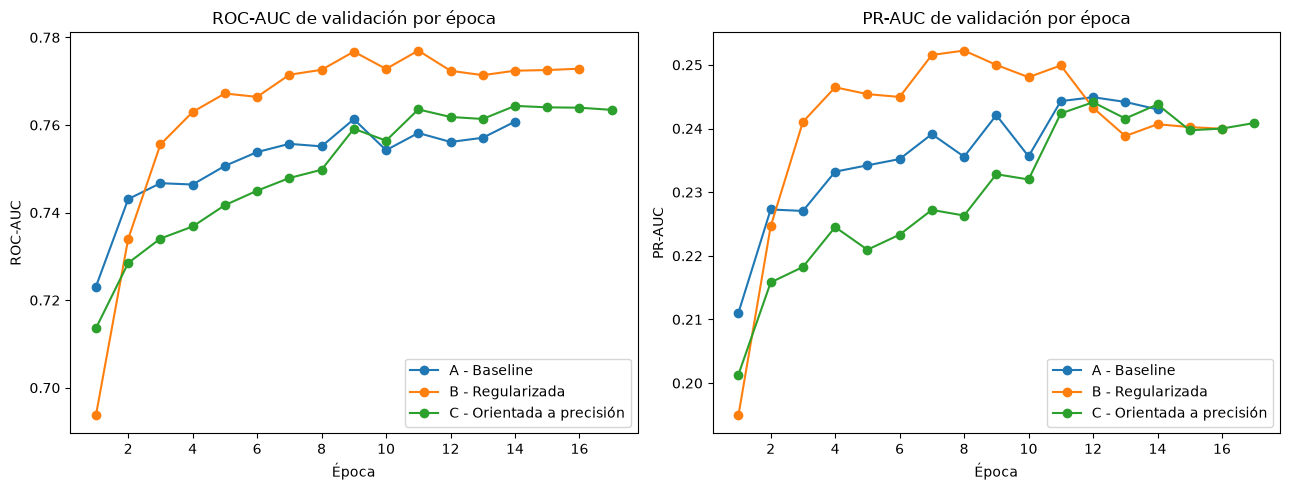

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nombre, historial in [("A - Baseline", historial_a), ("B - Regularizada", historial_b), ("C - Orientada a precisión", historial_c)]:
    axes[0].plot(historial["epoca"], historial["roc_auc_val"], marker="o", label=nombre)
    axes[1].plot(historial["epoca"], historial["pr_auc_val"], marker="o", label=nombre)

axes[0].set_title("ROC-AUC de validación por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("ROC-AUC")
axes[0].legend()

axes[1].set_title("PR-AUC de validación por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("PR-AUC")
axes[1].legend()

plt.tight_layout()
plt.savefig(ruta_figuras / "11_05_curvas_entrenamiento_mlp_refinamiento.png", dpi=150)
plt.show()

## 6. Comparación en validación (umbral 0,5)

In [10]:
def evaluar_red(modelo, nombre):
    modelo.eval()
    with torch.no_grad():
        logits = modelo(X_val_tensor)
        proba = torch.sigmoid(logits).cpu().numpy()

    prediccion = (proba >= 0.5).astype(int)

    return {
        "configuracion": nombre,
        "accuracy": accuracy_score(y_val, prediccion),
        "precision": precision_score(y_val, prediccion, zero_division=0),
        "recall": recall_score(y_val, prediccion, zero_division=0),
        "f1": f1_score(y_val, prediccion, zero_division=0),
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba),
    }


comparacion_mlp = pd.DataFrame([
    evaluar_red(modelo_a, "A - Baseline"),
    evaluar_red(modelo_b, "B - Regularizada"),
    evaluar_red(modelo_c, "C - Orientada a precisión"),
]).set_index("configuracion").round(3)

comparacion_mlp.to_csv(ruta_modelos / "comparacion_mlp_refinamiento_validacion.csv")
comparacion_mlp

,accuracy,precision,recall,f1,roc_auc,pr_auc
configuracion,,,,,,
A - Baseline,0.668,0.198,0.739,0.312,0.761,0.242
B - Regularizada,0.699,0.215,0.739,0.333,0.777,0.250
C - Orientada a precisión,0.823,0.260,0.399,0.314,0.762,0.244


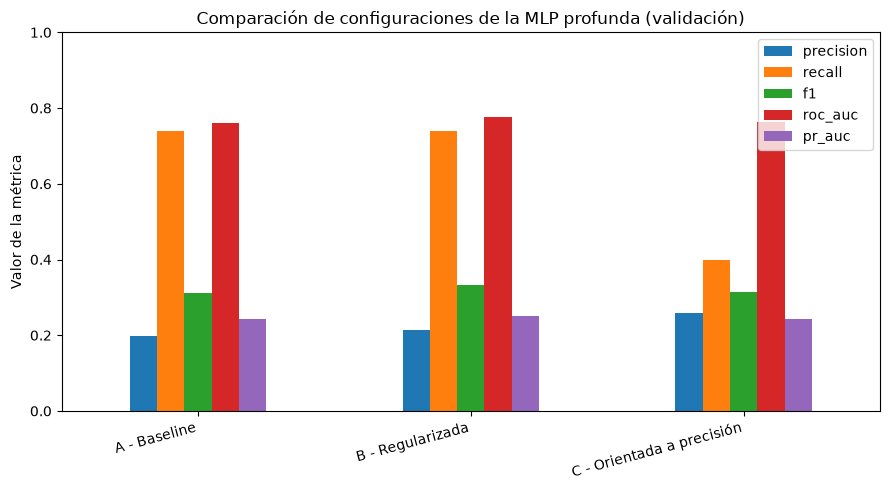

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
comparacion_mlp[["precision", "recall", "f1", "roc_auc", "pr_auc"]].plot(kind="bar", ax=ax)
ax.set_title("Comparación de configuraciones de la MLP profunda (validación)")
ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(ruta_figuras / "11_06_comparacion_mlp_validacion.png", dpi=150)
plt.show()

## 7. Guardado

Se guarda como `mlp_profunda_refinada.pt` la configuración con mejor F1 en
validación entre las tres (si ninguna de las variantes B o C supera a la
baseline A, se documenta esa conclusión igual y se guarda A). Ninguna de las
tres se evalúa sobre el conjunto de prueba: la prueba se reserva
exclusivamente para la evaluación final del modelo del proyecto (XGBoost +
ROS refinado, notebook 08).

In [12]:
mejor_configuracion = comparacion_mlp["f1"].idxmax()
modelos_por_nombre = {
    "A - Baseline": modelo_a,
    "B - Regularizada": modelo_b,
    "C - Orientada a precisión": modelo_c,
}

print(f"Mejor configuración por F1 en validación: {mejor_configuracion}")

torch.save(modelos_por_nombre[mejor_configuracion].state_dict(), ruta_modelos / "mlp_profunda_refinada.pt")
print("Guardada en models/mlp_profunda_refinada.pt")

Mejor configuración por F1 en validación: B - Regularizada
Guardada en models/mlp_profunda_refinada.pt


## 8. Conclusiones

La configuración **B (regularizada y más angosta)** ganó con el mejor F1 de las tres (0,333, frente a 0,312 de la baseline A), y no es una mejora que sacrifique otra métrica a cambio: precision, recall, ROC-AUC y PR-AUC son todos iguales o mejores que en A. Esto sugiere que una arquitectura más compacta y regularizada puede generalizar mejor en este conjunto de datos. Conviene ser cauteloso con la atribución causal: B cambió simultáneamente el ancho de la red, el dropout, el weight decay y agregó un programador de tasa de aprendizaje, por lo que este experimento no aísla cuál de esos cambios explica la mejora.

La configuración **C (pos_weight suavizado)** replica, a menor escala, el mismo problema que se encontró al ajustar el umbral de XGBoost en `06_refinamiento_modelo.ipynb`: relajar la penalización por errores en la clase minoritaria sube la accuracy y la precision (0,823 y 0,260), pero el recall cae de 0,739 a 0,40 — una pérdida de sensibilidad demasiado grande para el objetivo de negocio del proyecto. Como C también cambió la métrica de detención temprana (de ROC-AUC a PR-AUC) al mismo tiempo que el pos_weight, el resultado no confirma de forma aislada la importancia de penalizar fuerte la clase minoritaria, pero sí respalda esa idea: dos cambios orientados a favorecer la precision, aplicados juntos, produjeron la misma caída de recall observada en el ajuste de umbral de XGBoost.

En cualquier caso, ninguna de las tres variantes de la MLP profunda se acerca al desempeño de XGBoost + ROS (F1 0,387 en validación tras su propio refinamiento, frente al 0,333 de la mejor red aquí). Este ejercicio no cambia la conclusión del proyecto: XGBoost sigue siendo el modelo final. Lo que aporta es evidencia de que la arquitectura de la red también pasó por un proceso real de iteración y comparación, no solo la elección inicial del notebook 05.